In [ ]:
# Install standard libraries
!pip install pandas numpy scikit-learn matplotlib seaborn biopython gensim requests tqdm --quiet

# Install metapredict (Fast, robust IDR predictor)
!pip install metapredict --quiet

# Install NCBI BLAST+ and NCBI SEG (The specific tool needed for LCR)
print("Installing NCBI tools...")
!apt-get update -y -qq
!apt-get install -y ncbi-blast+ ncbi-seg -qq
print("Installation complete.")

import pandas as pd
import numpy as np
import os
import subprocess
import requests
import time
import math
from collections import Counter
from tqdm.notebook import tqdm

# Scikit-learn imports
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve

# Gensim for Word2Vec
from gensim.models import Word2Vec

# BioPython for sequence analysis
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Metapredict for IDR
import metapredict as meta

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\nAll libraries imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 30.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 kB 14.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 69.6 MB/s eta 0:00:00
Installing NCBI tools...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem 

In [ ]:
# # # ---------- CODE CELL: Upload, load, clean and combine datasets ----------

# # from google.colab import files
# # import os
# # import pandas as pd

# # # -- 1) Upload (if missing) --
# # required_files = ['llps_plus.csv', 'llps_minus.csv', 'pdb.csv']
# # missing = [f for f in required_files if not os.path.exists(f)]
# # if missing:
# #     print("Please upload the missing CSV files:", missing)
# #     uploaded = files.upload()
# #     # write any uploaded files to disk (Colab already does this, but safe to write)
# #     for fn, content in uploaded.items():
# #         with open(fn, 'wb') as fh:
# #             fh.write(content)
# #         print(f'User uploaded file "{fn}" ({len(content)} bytes)')
# # else:
# #     print("All required files already present in the environment.")

# # try:
# #     df_plus = pd.read_csv('llps_plus.csv')
# #     df_minus = pd.read_csv('llps_minus.csv')
# #     df_pdb = pd.read_csv('pdb.csv')
# #     print(f"Loaded files: {len(df_plus)} rows (llps_plus), {len(df_minus)} rows (llps_minus), {len(df_pdb)} rows (pdb)")
# # except Exception as e:
# #     raise RuntimeError("Failed to read one or more CSV files. Check filenames and CSV format.") from e

# # def clean_sequence(sequence):
# #     if not isinstance(sequence, str):
# #         return None
# #     valid_chars = set("ACDEFGHIKLMNPQRSTVWYUO")
# #     cleaned = ''.join([c.upper() for c in sequence if c.upper() in valid_chars])
# #     return cleaned if len(cleaned) > 10 else None

# # df_plus = df_plus.copy()
# # df_minus = df_minus.copy()
# # df_pdb = df_pdb.copy()

# # df_plus['Label']  = 1
# # df_plus['Source'] = 'llps_plus'

# # df_minus['Label'] = 0
# # df_minus['Source'] = 'llps_minus'

# # df_pdb['Label']   = 0
# # df_pdb['Source']  = 'pdb'

# # # ---------- 4) Concatenate ----------
# # df_combined = pd.concat([df_plus, df_minus, df_pdb], ignore_index=True)

# # # ---------- 5) Detect sequence column robustly ----------
# # # prefer 'Sequence' (case-sensitive), then case-insensitive matches, then any col containing 'seq'
# # candidate_cols = [c for c in df_combined.columns if c == 'Sequence' or c.lower() == 'sequence' or 'seq' in c.lower()]
# # if len(candidate_cols) == 0:
# #     raise KeyError("No sequence-like column found. Rename your sequence column to 'Sequence' or include 'seq' in the column name.")
# # sequence_column = candidate_cols[0]
# # print(f"Using column '{sequence_column}' as the sequence column.")

# # # ---------- 6) Create a cleaned sequence column and filter invalid sequences ----------
# # df_combined['Clean_Sequence'] = df_combined[sequence_column].astype(str).apply(clean_sequence)

# # before = len(df_combined)
# # df_combined.dropna(subset=['Clean_Sequence'], inplace=True)
# # after = len(df_combined)
# # print(f"Removed {before - after} rows with invalid or too-short sequences after cleaning.")

# # # ---------- 7) Remove duplicates (on cleaned sequence) ----------
# # before_dup = len(df_combined)
# # df_combined.drop_duplicates(subset=['Clean_Sequence'], inplace=True)
# # after_dup = len(df_combined)
# # print(f"Removed {before_dup - after_dup} duplicate sequences (based on Clean_Sequence).")

# # # ---------- 8) Finalize DataFrame for downstream steps ----------AAA
# # # rename Clean_Sequence -> Sequence (so downstream code uses 'Sequence')
# # df_main = df_combined.copy()
# # df_main.rename(columns={'Clean_Sequence': 'Sequence'}, inplace=True)

# # # If you want to drop the original raw sequence column to avoid confusion:
# # if sequence_column != 'Sequence':
# #     # we already renamed Clean_Sequence to Sequence, so keep that and optionally drop original
# #     df_main.drop(columns=[sequence_column], errors='ignore', inplace=True)

# # # ---------- 9) Quick overview ----------
# # print("\nFinal dataset sample:")
# # display(df_main.head())

# # print("\nLabel distribution:")
# # print(df_main['Label'].value_counts())

# # print("\nNegative-class composition by source (Label==0):")
# # print(df_main[df_main['Label'] == 0]['Source'].value_counts())

# # # df_main is now ready for feature extraction / modeling
# # ---------- CODE CELL: Upload and load merged dataset ----------

# from google.colab import files
# import os
# import pandas as pd

# # ---------- 1) Upload (if missing) ----------
# if not os.path.exists('merged_llps_unique.csv'):
#     print("Please upload merged_llps_unique.csv")
#     uploaded = files.upload()
#     for fn, content in uploaded.items():
#         with open(fn, 'wb') as fh:
#             fh.write(content)
#         print(f'User uploaded file "{fn}" ({len(content)} bytes)')
# else:
#     print("File already present in the environment.")

# # ---------- 2) Load ----------
# try:
#     df_main = pd.read_csv('merged_llps_unique.csv')
#     print(f"Loaded {len(df_main)} rows.")
# except Exception as e:
#     raise RuntimeError("Failed to read merged_llps_unique.csv. Check filename and format.") from e

# # ---------- 3) Quick overview ----------
# print("\nFinal dataset sample:")
# display(df_main.head())

# print("\nLabel distribution:")
# print(df_main['Label'].value_counts())

# print("\nSource breakdown:")
# print(df_main['Source'].value_counts())

# print("\nNegative-class composition (Label==0):")
# print(df_main[df_main['Label'] == 0]['Source'].value_counts())

# # df_main is now ready for feature extraction / modelling
# ---------- CODE CELL: Upload and load merged dataset ----------

from google.colab import files
import os
import pandas as pd

# ---------- 1) Upload (if missing) ----------
if not os.path.exists('merged_llps_unique.csv'):
    print("Please upload merged_llps_unique.csv")
    uploaded = files.upload()
    for fn, content in uploaded.items():
        with open(fn, 'wb') as fh:
            fh.write(content)
        print(f'User uploaded file "{fn}" ({len(content)} bytes)')
else:
    print("File already present in the environment.")

# ---------- 2) Load ----------
try:
    df_main = pd.read_csv('merged_llps_unique.csv')
    print(f"Loaded {len(df_main)} rows.")
except Exception as e:
    raise RuntimeError("Failed to read merged_llps_unique.csv. Check filename and format.") from e

# ---------- 3) Standardise column names to Title Case ----------
df_main.rename(columns={
    'sequence':   'Sequence',
    'uniprot_id': 'Uniprot_ID',
    'label':      'Label',
    'pdb':        'PDB',
    'seq_len':    'Seq_Len',
    'source':     'Source',
}, inplace=True)

# ---------- 4) Quick overview ----------
print("\nFinal dataset sample:")
display(df_main.head())

print("\nLabel distribution:")
print(df_main['Label'].value_counts())

print("\nNegative-class composition (Label==0):")
print(df_main[df_main['Label'] == 0]['Uniprot_ID'].count(), "proteins")

# df_main is now ready for feature extraction / modelling

Please upload merged_llps_unique.csv


Saving merged_llps_unique.csv to merged_llps_unique.csv
User uploaded file "merged_llps_unique.csv" (3233689 bytes)
Loaded 6289 rows.

Final dataset sample:


,Sequence,Uniprot_ID,Label,PDB,Seq_Len
0,MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTD...,P35637,1,NaN,267.0
1,MAASFPSPSAINNNKWYFTREQIENSPSRRAGLDPDKELSYRQQAA...,A0A1S3LKS2,1,NaN,699.0
2,AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKK...,P05453,1,NaN,571.0
3,CLRKKRKPQAEKVDVIAGSSKMKGFSSSESESSSESSSSDSEDSET...,O60885,1,NaN,678.0
4,DFDVYVLAKLLGFASEELQEEIEIIRDNVTDAFEACKPLLKKLMIE...,G5EBV6,1,NaN,529.0



Label distribution:
Label
0    4007
1    2282
Name: count, dtype: int64

Negative-class composition (Label==0):
4007 proteins


In [ ]:
# (fixed) ----------
from tqdm.notebook import tqdm

def calculate_sequence_length(sequence):
    """Calculates the length of the sequence."""
    # Handle arrays/lists by converting to string or getting first element
    if isinstance(sequence, (list, np.ndarray)):
        if len(sequence) > 0:
            sequence = sequence[0] if isinstance(sequence, np.ndarray) else sequence[0]
        else:
            return 0
    return len(sequence) if isinstance(sequence, str) else 0

def calculate_hydrophobicity(sequence):
    if isinstance(sequence, (list, np.ndarray)):
        if len(sequence) > 0:
            sequence = sequence[0] if isinstance(sequence, np.ndarray) else sequence[0]
        else:
            return np.nan
    try:
        return ProteinAnalysis(sequence).gravy()
    except Exception:
        return np.nan  # handle potential errors for non-standard sequences

def calculate_shannon_entropy(sequence):
    """Calculates the Shannon entropy of the sequence."""
    # Handle arrays/lists
    if isinstance(sequence, (list, np.ndarray)):
        if len(sequence) > 0:
            sequence = sequence[0] if isinstance(sequence, np.ndarray) else sequence[0]
        else:
            return 0.0

    # Now check for empty/invalid sequences
    if sequence is None or not isinstance(sequence, str) or len(sequence) == 0:
        return 0.0

    counts = Counter(sequence)
    total_len = len(sequence)
    entropy = 0.0
    for count in counts.values():
        p_i = count / total_len
        entropy -= p_i * math.log2(p_i)
    return entropy

# Check for missing sequences
print(f"Total rows: {len(df_main)}")
print(f"Sample sequence type: {type(df_main['Sequence'].iloc[0])}")
print(f"Sample sequence value: {df_main['Sequence'].iloc[0]}")

# Apply these functions using .values to iterate over all rows (including NaN)
print("\nCalculating sequence lengths...")
df_main['Length'] = [calculate_sequence_length(seq) for seq in tqdm(df_main['Sequence'].values, desc="Length")]

print("Calculating hydrophobicity...")
df_main['Hydrophobicity'] = [calculate_hydrophobicity(seq) for seq in tqdm(df_main['Sequence'].values, desc="Hydrophobicity")]

print("Calculating Shannon entropy...")
df_main['ShannonEntropy'] = [calculate_shannon_entropy(seq) for seq in tqdm(df_main['Sequence'].values, desc="Shannon Entropy")]

print("\nGlobal features calculated:")
display(df_main[['Sequence', 'Length', 'Hydrophobicity', 'ShannonEntropy']].head(10))

Total rows: 6289
Sample sequence type: <class 'str'>
Sample sequence value: MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDTSGYGQSSYSSYGQSQNTGYGTQSTPQGYGSTGGYGSSQSSQSSYGQQSSYPGYGQQPAPSSTSGSYGSSSQSSSYGQPQSGSYSQQPSYGGQQQSYGQQQSYNPPQGYGQQNQYNSSSGGGGGGGGGGNYGQDQSSMSSGGGSGGGYGNQDQSGGGGSGGYGQQDRGGRGRGGSGGGGGGGGGGYNRSSGGYEPRGRGGGRGGRGGMGGSDRGGFNKFGG

Calculating sequence lengths...


Length:   0%|          | 0/6289 [00:00<?, ?it/s]

Calculating hydrophobicity...


Hydrophobicity:   0%|          | 0/6289 [00:00<?, ?it/s]

Calculating Shannon entropy...


Shannon Entropy:   0%|          | 0/6289 [00:00<?, ?it/s]


Global features calculated:


,Sequence,Length,Hydrophobicity,ShannonEntropy
0,MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTD...,267,-1.398876,2.873894
1,MAASFPSPSAINNNKWYFTREQIENSPSRRAGLDPDKELSYRQQAA...,699,-0.659227,4.059970
2,AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKK...,571,-0.559895,4.086236
3,CLRKKRKPQAEKVDVIAGSSKMKGFSSSESESSSESSSSDSEDSET...,678,-1.237316,3.669713
4,DFDVYVLAKLLGFASEELQEEIEIIRDNVTDAFEACKPLLKKLMIE...,529,-0.368242,4.023415
5,EHHSGSQGPLLTTGDLGKEKTQKRVKEGNGTSNSTLSGPGLDSKPG...,627,-1.131419,3.593170
6,EPADPFISLLMDPLEESVGKVVNHIAQLFEEASKNEGDESLVLRSQ...,516,-0.487597,4.034462
7,ESNQSNNGGSGNAALNRGGRYVPPHLRGGDGGAAAAASAGGDDRRG...,167,-1.728144,2.886690
8,FSPTSPTYSPTSPAYSPTSPSYSPTSPSYSPTSPSYSPTSPSYSPT...,192,-1.205729,2.472315
9,GPLGSMEDSMDMDMSPLRPQNYLFGCELKADKDYHFKVDNDENEHQ...,245,-1.028571,3.931549


In [ ]:
# Install the Python library for IDR prediction
!pip install metapredict --quiet

# Install the system tool for LCR (SEG)
!apt-get update -y -qq
!apt-get install -y ncbi-seg -qq

print("Installation complete.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Installation complete.


In [ ]:
import pandas as pd
import shutil
import subprocess
import os
import metapredict as meta
from tqdm.notebook import tqdm

# --- STEP 1: Fix Duplicate "Sequence" Columns ---
# Check if 'Sequence' is duplicated (returns a DataFrame instead of Series)
if isinstance(df_main['Sequence'], pd.DataFrame):
    print("⚠️ Duplicate 'Sequence' columns detected. Fixing...")

    # We take the *last* column named 'Sequence' (usually the cleaned one)
    real_sequences = df_main['Sequence'].iloc[:, -1].copy()

    # Drop all columns named 'Sequence' to reset
    df_main = df_main.loc[:, df_main.columns != 'Sequence']

    # Add back the single correct column
    df_main['Sequence'] = real_sequences
    print("✅ DataFrame fixed. 'Sequence' is now unique.")
else:
    print("✅ 'Sequence' column is already unique.")

# --- STEP 2: Define Functions ---

def calculate_lcr_fraction(sequence, seq_id="temp_seq"):
    if not isinstance(sequence, str) or len(sequence) == 0:
        return 0.0

    # Locate seg tool
    seg_command = "seg"
    if shutil.which("seg") is None:
        if shutil.which("ncbi-seg") is not None:
            seg_command = "ncbi-seg"
        else:
            # Fallback: if seg is missing, return 0.0 (or raise error)
            return 0.0

    fasta_in = f"{seq_id}.fasta"
    fasta_out = f"{seq_id}.seg.fasta"

    try:
        with open(fasta_in, "w") as f:
            f.write(f">{seq_id}\n{sequence}\n")

        # Run SEG
        subprocess.run(f"{seg_command} {fasta_in} -x > {fasta_out}",
                       shell=True, check=True, stderr=subprocess.DEVNULL)

        with open(fasta_out, "r") as f:
            lines = f.readlines()
            masked = "".join(line.strip() for line in lines if not line.startswith('>'))

        return masked.lower().count('x') / len(sequence)

    except Exception:
        return 0.0
    finally:
        if os.path.exists(fasta_in): os.remove(fasta_in)
        if os.path.exists(fasta_out): os.remove(fasta_out)

def calculate_idr_fraction(sequence):
    if not isinstance(sequence, str) or len(sequence) == 0:
        return 0.0
    try:
        scores = meta.predict_disorder(sequence)
        return sum(1 for s in scores if s > 0.5) / len(sequence)
    except:
        return 0.0

# --- STEP 3: Run Calculations ---

print("\nCalculating LCR Fraction...")
df_main['LCR_Fraction'] = [
    calculate_lcr_fraction(seq, f"seq_{i}")
    for i, seq in tqdm(enumerate(df_main['Sequence'].values), total=len(df_main))
]

print("\nCalculating IDR Fraction...")
df_main['IDR_Fraction'] = [
    calculate_idr_fraction(seq)
    for seq in tqdm(df_main['Sequence'].values, total=len(df_main))
]

# --- STEP 4: Inspect Results ---
print("\nResults Sample:")
display(df_main[['Sequence', 'LCR_Fraction', 'IDR_Fraction']].head())

✅ 'Sequence' column is already unique.

Calculating LCR Fraction...


  0%|          | 0/6289 [00:00<?, ?it/s]


Calculating IDR Fraction...


  0%|          | 0/6289 [00:00<?, ?it/s]


Results Sample:


,Sequence,LCR_Fraction,IDR_Fraction
0,MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTD...,0.913858,1.000000
1,MAASFPSPSAINNNKWYFTREQIENSPSRRAGLDPDKELSYRQQAA...,0.288984,0.610873
2,AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKK...,0.148862,0.246935
3,CLRKKRKPQAEKVDVIAGSSKMKGFSSSESESSSESSSSDSEDSET...,0.529499,0.994100
4,DFDVYVLAKLLGFASEELQEEIEIIRDNVTDAFEACKPLLKKLMIE...,0.189036,0.470699


✅ merged_llps_unique.csv already present in the environment.

Loading dataset...
✅ Total sequences loaded: 6289

Label distribution:
Label
0    4007
1    2282
Name: count, dtype: int64

Calculating features...


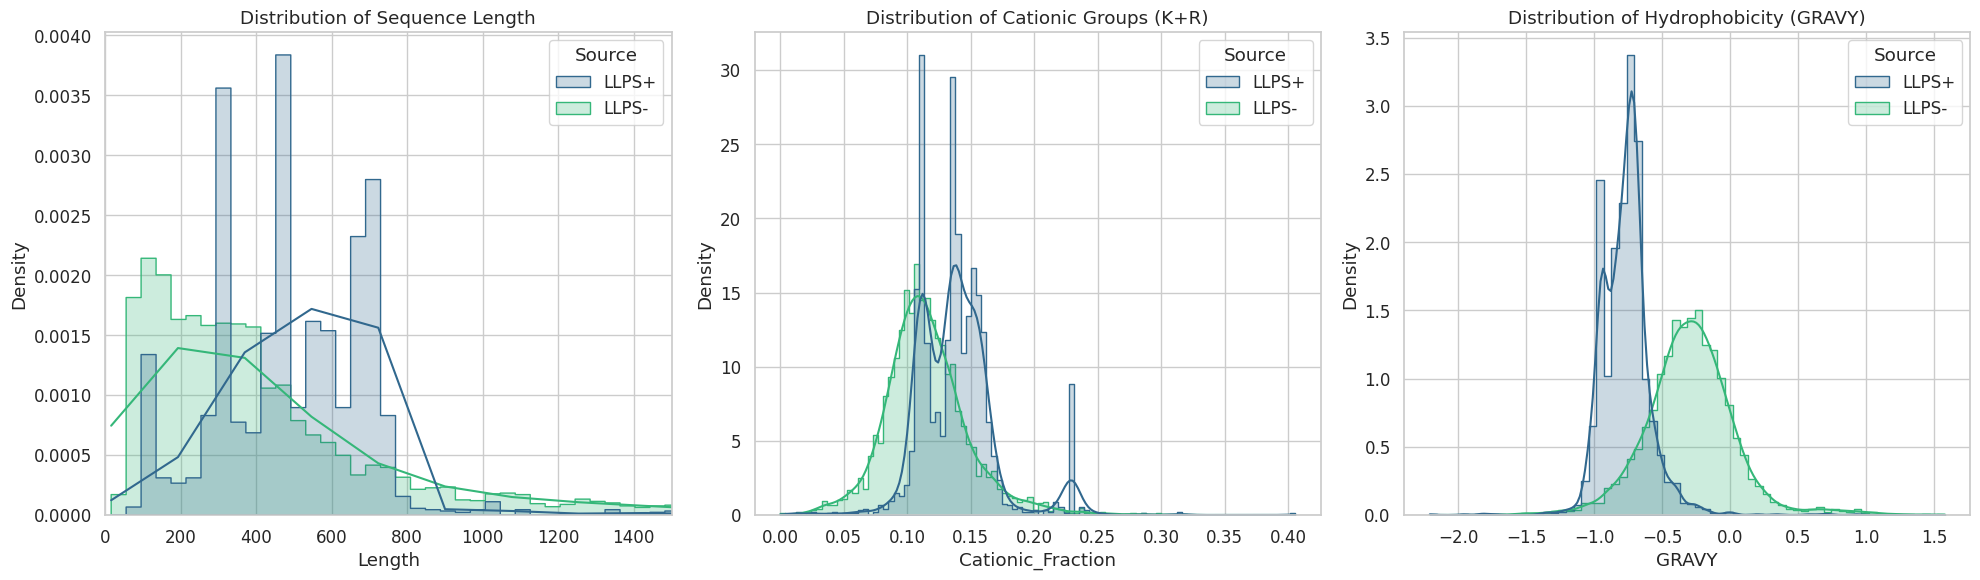

In [ ]:
# # @title Install Dependencies and Import Libraries
# !pip install biopython seaborn matplotlib pandas numpy --quiet

# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt
# from Bio.SeqUtils.ProtParam import ProteinAnalysis
# from google.colab import files
# import os
# import io

# # Set the visual style
# sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

# # --------------------------------------------------------------------------------
# # 1. CHECK AND UPLOAD FILES
# # --------------------------------------------------------------------------------
# required_files = ['llps_plus.csv', 'llps_minus.csv', 'pdb.csv']
# uploaded_data = {}

# print("Checking for required files...")
# for filename in required_files:
#     if os.path.exists(filename):
#         print(f"✅ Found {filename}")
#     else:
#         print(f"⚠️ {filename} is missing. Please upload it now.")
#         uploaded = files.upload()
#         for name, content in uploaded.items():
#             # Save the uploaded file to disk so pandas can read it
#             with open(name, 'wb') as f:
#                 f.write(content)
#             print(f"✅ Uploaded {name}")

# # --------------------------------------------------------------------------------
# # 2. LOAD DATASETS
# # --------------------------------------------------------------------------------
# print("\nLoading datasets...")

# def load_csv_safe(filename, source_label, sep=','):
#     try:
#         df = pd.read_csv(filename, sep=sep)
#         df['Source'] = source_label
#         # Standardize sequence column name
#         if 'seq' in df.columns:
#             df.rename(columns={'seq': 'Sequence'}, inplace=True)
#         return df
#     except Exception as e:
#         print(f"❌ Error loading {filename}: {e}")
#         return pd.DataFrame(columns=['Sequence', 'Source'])

# df_plus = load_csv_safe('llps_plus.csv', 'LLPS+')
# df_minus = load_csv_safe('llps_minus.csv', 'LLPS-')
# df_pdb = load_csv_safe('pdb.csv', 'PDB', sep='\t') # pdb.csv is often tab-separated

# # Combine datasets
# df_combined = pd.concat([df_plus, df_minus, df_pdb], ignore_index=True)
# print(f"Total sequences loaded: {len(df_combined)}")

# # --------------------------------------------------------------------------------
# # 3. FEATURE CALCULATION
# # --------------------------------------------------------------------------------
# def calculate_physicochemical_properties(seq):
#     if not isinstance(seq, str) or len(seq) == 0:
#         return pd.Series([np.nan, np.nan, np.nan])

#     seq = seq.upper()
#     standard_aas = set("ACDEFGHIKLMNPQRSTVWY")
#     cleaned_seq = "".join([aa for aa in seq if aa in standard_aas])

#     if len(cleaned_seq) == 0:
#         return pd.Series([0, 0, np.nan])

#     length = len(cleaned_seq)a
#     num_cationic = cleaned_seq.count('K') + cleaned_seq.count('R')
#     cationic_fraction = num_cationic / length

#     try:
#         X = ProteinAnalysis(cleaned_seq)
#         gravy = X.gravy()
#     except:
#         gravy = np.nan

#     return pd.Series([length, cationic_fraction, gravy])

# print("Calculating features...")
# if not df_combined.empty:
#     df_combined[['Length', 'Cationic_Fraction', 'GRAVY']] = df_combined['Sequence'].apply(calculate_physicochemical_properties)
#     df_combined.dropna(subset=['Length', 'GRAVY'], inplace=True)

# # --------------------------------------------------------------------------------
# # 4. PLOTTING
# # --------------------------------------------------------------------------------
# if not df_combined.empty:
#     fig, axes = plt.subplots(1, 3, figsize=(20, 6))

#     # Plot A: Sequence Length
#     sns.histplot(data=df_combined, x="Length", hue="Source", element="step", stat="density", common_norm=False, kde=True, ax=axes[0], palette="viridis")
#     axes[0].set_title('Distribution of Sequence Length')
#     axes[0].set_xlim(0, 1500)

#     # Plot B: Cationic Groups
#     sns.histplot(data=df_combined, x="Cationic_Fraction", hue="Source", element="step", stat="density", common_norm=False, kde=True, ax=axes[1], palette="viridis")
#     axes[1].set_title('Distribution of Cationic Groups (K+R)')

#     # Plot C: Hydrophobicity (GRAVY)
#     sns.histplot(data=df_combined, x="GRAVY", hue="Source", element="step", stat="density", common_norm=False, kde=True, ax=axes[2], palette="viridis")
#     axes[2].set_title('Distribution of Hydrophobicity (GRAVY)')

#     plt.tight_layout()
#     plt.show()
# else:
#     print("No data to plot.")
# @title Install Dependencies and Import Libraries
!pip install biopython seaborn matplotlib pandas numpy --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from google.colab import files
import os

# Set the visual style
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

# --------------------------------------------------------------------------------
# 1. CHECK AND UPLOAD MERGED FILE
# --------------------------------------------------------------------------------
if not os.path.exists('merged_llps_unique.csv'):
    print("⚠️ merged_llps_unique.csv is missing. Please upload it now.")
    uploaded = files.upload()
    for name, content in uploaded.items():
        with open(name, 'wb') as f:
            f.write(content)
        print(f'✅ Uploaded "{name}" ({len(content)} bytes)')
else:
    print("✅ merged_llps_unique.csv already present in the environment.")

# --------------------------------------------------------------------------------
# 2. LOAD DATASET
# --------------------------------------------------------------------------------
print("\nLoading dataset...")
try:
    df_combined = pd.read_csv('merged_llps_unique.csv')

    # Standardise column names to Title Case
    df_combined.rename(columns={
        'sequence':   'Sequence',
        'uniprot_id': 'Uniprot_ID',
        'label':      'Label',
        'pdb':        'PDB',
        'seq_len':    'Seq_Len',
        'source':     'Source',
    }, inplace=True)

    # Map numeric label to source-style string for plotting (matches original hue logic)
    df_combined['Source'] = df_combined['Label'].map({1: 'LLPS+', 0: 'LLPS-'})

    print(f"✅ Total sequences loaded: {len(df_combined)}")
    print(f"\nLabel distribution:\n{df_combined['Label'].value_counts()}")
except Exception as e:
    raise RuntimeError("❌ Failed to read merged_llps_unique.csv. Check filename and format.") from e

# --------------------------------------------------------------------------------
# 3. FEATURE CALCULATION
# --------------------------------------------------------------------------------
def calculate_physicochemical_properties(seq):
    if not isinstance(seq, str) or len(seq) == 0:
        return pd.Series([np.nan, np.nan, np.nan])

    seq = seq.upper()
    standard_aas = set("ACDEFGHIKLMNPQRSTVWY")
    cleaned_seq = "".join([aa for aa in seq if aa in standard_aas])

    if len(cleaned_seq) == 0:
        return pd.Series([0, 0, np.nan])

    length = len(cleaned_seq)
    num_cationic = cleaned_seq.count('K') + cleaned_seq.count('R')
    cationic_fraction = num_cationic / length

    try:
        X = ProteinAnalysis(cleaned_seq)
        gravy = X.gravy()
    except:
        gravy = np.nan

    return pd.Series([length, cationic_fraction, gravy])

print("\nCalculating features...")
if not df_combined.empty:
    df_combined[['Length', 'Cationic_Fraction', 'GRAVY']] = df_combined['Sequence'].apply(calculate_physicochemical_properties)
    df_combined.dropna(subset=['Length', 'GRAVY'], inplace=True)

# --------------------------------------------------------------------------------
# 4. PLOTTING
# --------------------------------------------------------------------------------
if not df_combined.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Plot A: Sequence Length
    sns.histplot(data=df_combined, x="Length", hue="Source", element="step", stat="density", common_norm=False, kde=True, ax=axes[0], palette="viridis")
    axes[0].set_title('Distribution of Sequence Length')
    axes[0].set_xlim(0, 1500)

    # Plot B: Cationic Groups
    sns.histplot(data=df_combined, x="Cationic_Fraction", hue="Source", element="step", stat="density", common_norm=False, kde=True, ax=axes[1], palette="viridis")
    axes[1].set_title('Distribution of Cationic Groups (K+R)')

    # Plot C: Hydrophobicity (GRAVY)
    sns.histplot(data=df_combined, x="GRAVY", hue="Source", element="step", stat="density", common_norm=False, kde=True, ax=axes[2], palette="viridis")
    axes[2].set_title('Distribution of Hydrophobicity (GRAVY)')

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot.")

In [ ]:
import subprocess
import os
import shutil
import numpy as np
import pandas as pd
from collections import Counter
from tqdm.notebook import tqdm

# 1. Define the specific groups from Saar et al. 2021 (Methods section)
AA_GROUPS = {
    'Polar': set("SQNGCTP"),
    'Hydrophobic': set("AILMFV"),
    'Aromatic': set("WYF"),
    'Cationic': set("KRH"),
    'Anionic': set("DE")
}

def analyze_lcr_properties(sequence, seq_id="temp"):
    """
    Runs SEG to find LCRs, then calculates the fraction of specific
    amino acid groups WITHIN those LCRs (as per Saar et al. 2021).
    """
    if not isinstance(sequence, str) or len(sequence) == 0:
        return pd.Series([0.0]*6, index=['LCR_Fraction', 'LCR_Polar', 'LCR_Hydrophobic', 'LCR_Aromatic', 'LCR_Cationic', 'LCR_Anionic'])

    # Write to file
    fasta_in = f"{seq_id}.fasta"
    fasta_out = f"{seq_id}.seg.fasta"
    with open(fasta_in, "w") as f:
        f.write(f">{seq_id}\n{sequence}\n")

    # Run SEG with -x to get the mask
    # We need to know WHERE the LCRs are to analyze their content
    seg_cmd = "seg" if shutil.which("seg") else "ncbi-seg"

    try:
        subprocess.run(f"{seg_cmd} {fasta_in} -x > {fasta_out}",
                       shell=True, check=True, stderr=subprocess.DEVNULL)

        with open(fasta_out, "r") as f:
            lines = f.readlines()
            # Reconstruct masked sequence (removing header)
            masked_seq = "".join(line.strip() for line in lines if not line.startswith('>'))

        # Safety check: lengths must match
        if len(masked_seq) != len(sequence):
            return pd.Series([0.0]*6)

        # Extract ONLY the residues that correspond to 'x' in the mask
        # This gives us the actual amino acid sequence of the LCRs
        lcr_residues = [original_aa for original_aa, mask_char in zip(sequence, masked_seq) if mask_char.lower() == 'x']

        lcr_len = len(lcr_residues)
        total_len = len(sequence)

        # 1. LCR Fraction (Global)
        lcr_fraction = lcr_len / total_len if total_len > 0 else 0.0

        # 2. Composition INSIDE LCRs
        # If no LCRs exist, these fractions are 0
        if lcr_len == 0:
            feats = [0.0] * 5
        else:
            # Count occurrence of each group in the LCR residues
            feats = []
            for name, group_set in AA_GROUPS.items():
                count = sum(1 for aa in lcr_residues if aa.upper() in group_set)
                feats.append(count / lcr_len) # Fraction relative to LCR length

        return pd.Series([lcr_fraction] + feats,
                         index=['LCR_Fraction', 'LCR_Polar', 'LCR_Hydrophobic', 'LCR_Aromatic', 'LCR_Cationic', 'LCR_Anionic'])

    except Exception as e:
        return pd.Series([0.0]*6)
    finally:
        if os.path.exists(fasta_in): os.remove(fasta_in)
        if os.path.exists(fasta_out): os.remove(fasta_out)

# Apply to dataframe
print("Analyzing LCR Composition (Saar et al. Methodology)...")
lcr_features = df_combined['Sequence'].apply(lambda s: analyze_lcr_properties(s))
df_combined = pd.concat([df_combined, lcr_features], axis=1)

print("\nNew Features Extracted:")
display(df_combined[['Sequence', 'LCR_Fraction', 'LCR_Polar', 'LCR_Cationic']].head())

Analyzing LCR Composition (Saar et al. Methodology)...

New Features Extracted:


,Sequence,LCR_Fraction,LCR_Polar,LCR_Cationic
0,MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTD...,0.913858,0.819672,0.036885
1,MAASFPSPSAINNNKWYFTREQIENSPSRRAGLDPDKELSYRQQAA...,0.288984,0.569307,0.173267
2,AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKK...,0.148862,0.270588,0.223529
3,CLRKKRKPQAEKVDVIAGSSKMKGFSSSESESSSESSSSDSEDSET...,0.529499,0.582173,0.122563
4,DFDVYVLAKLLGFASEELQEEIEIIRDNVTDAFEACKPLLKKLMIE...,0.189036,0.620000,0.140000


In [ ]:
from gensim.models import Word2Vec
import numpy as np
import pandas as pd
from tqdm import tqdm
import time

# ------------------------------------------------------------------------------
# 1. TOKENIZATION FUNCTION (Overlapping 3-grams)
# ------------------------------------------------------------------------------
def get_3grams(sequence):
    if not isinstance(sequence, str) or len(sequence) < 3:
        return []
    return [sequence[i:i+3] for i in range(len(sequence) - 2)]

# ------------------------------------------------------------------------------
# 2. PREPARE CORPUS
# ------------------------------------------------------------------------------
print("Tokenizing sequences for Word2Vec training...")
corpus = [get_3grams(seq) for seq in df_combined['Sequence']]
corpus = [sent for sent in corpus if sent]

print(f"Training Word2Vec model on {len(corpus)} sequences...")

# ------------------------------------------------------------------------------
# 3. TRAIN WORD2VEC MODEL (OPTIMIZED)
# ------------------------------------------------------------------------------
start_time = time.time()

w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=100,     # reduced from 200 → faster
    window=5,            # reduced from 25 → MUCH faster
    min_count=2,         # ignore rare grams → faster & cleaner
    workers=4,           # use multiple CPU cores
    sg=0,                # CBOW → faster than skip-gram
    epochs=10            # reduced from 30 → enough for this dataset
)

print(f"✅ Word2Vec model trained in {time.time() - start_time:.2f} seconds.")

# ------------------------------------------------------------------------------
# 4. GENERATE EMBEDDINGS (SUM OF VECTORS)
# ------------------------------------------------------------------------------
def get_protein_embedding(sequence, model):
    grams = get_3grams(sequence)

    if not grams:
        return np.zeros(model.vector_size)

    vectors = [model.wv[g] for g in grams if g in model.wv]

    if not vectors:
        return np.zeros(model.vector_size)

    return np.sum(vectors, axis=0)

print("Generating embedding vectors for all proteins...")

embedding_list = [
    get_protein_embedding(seq, w2v_model)
    for seq in tqdm(df_combined['Sequence'])
]

X_embeddings = np.vstack(embedding_list)

# ------------------------------------------------------------------------------
# 5. CREATE FINAL DATAFRAME
# ------------------------------------------------------------------------------
embedding_cols = [f'dim_{i}' for i in range(w2v_model.vector_size)]

df_embeddings = pd.DataFrame(
    X_embeddings,
    columns=embedding_cols,
    index=df_combined.index
)

df_final = pd.concat([df_combined, df_embeddings], axis=1)

# ------------------------------------------------------------------------------
# 6. OUTPUT
# ------------------------------------------------------------------------------
print(f"\n✅ Generated Embeddings matrix shape: {X_embeddings.shape}")
display(df_final[['Sequence'] + embedding_cols[:5]].head())

Tokenizing sequences for Word2Vec training...
Training Word2Vec model on 6289 sequences...
✅ Word2Vec model trained in 60.73 seconds.
Generating embedding vectors for all proteins...


100%|██████████| 6289/6289 [00:06<00:00, 1037.63it/s]


✅ Generated Embeddings matrix shape: (6289, 100)


,Sequence,dim_0,dim_1,dim_2,dim_3,dim_4
0,MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTD...,-137.652206,-248.425446,27.751425,-69.216644,-189.159073
1,MAASFPSPSAINNNKWYFTREQIENSPSRRAGLDPDKELSYRQQAA...,115.266411,-145.949539,-40.268742,-191.957291,-110.402840
2,AGFQPQSQGMSLNDFQKQQKQAAPKPKKTLKLVSSSGIKLANATKK...,53.385361,-173.277283,-153.643845,1.266796,286.038361
3,CLRKKRKPQAEKVDVIAGSSKMKGFSSSESESSSESSSSDSEDSET...,474.600952,-2.850028,-269.241516,-353.832062,429.206604
4,DFDVYVLAKLLGFASEELQEEIEIIRDNVTDAFEACKPLLKKLMIE...,87.970795,-256.211823,-96.570930,-101.672783,95.739914


In [ ]:
import pandas as pd
import numpy as np
import metapredict as meta
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from collections import Counter
from tqdm.notebook import tqdm

# 1. Define calculation functions for the missing features
def calculate_shannon_entropy(seq):
    """Calculates Shannon Entropy (measure of sequence complexity)."""
    if not seq or pd.isna(seq): return 0.0
    seq = seq.upper()
    L = len(seq)
    counts = Counter(seq)
    entropy = 0.0
    for count in counts.values():
        p = count / L
        entropy -= p * np.log2(p)
    return entropy

def calculate_hydrophobicity_sum(seq):
    """
    Calculates SUM of hydrophobicity (Kyte-Doolittle) as per Saar et al. paper.
    (Note: The paper uses Sum, not Average/GRAVY).
    """
    if not seq or pd.isna(seq): return 0.0
    # KD Scale
    kd = {'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5, 'C': 2.5,
          'Q': -3.5, 'E': -3.5, 'G': -0.4, 'H': -3.2, 'I': 4.5,
          'L': 3.8, 'K': -3.9, 'M': 1.9, 'F': 2.8, 'P': -1.6,
          'S': -0.8, 'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2}
    return sum(kd.get(aa.upper(), 0) for aa in seq)

def calculate_idr_fraction(seq):
    """Calculates fraction of disordered residues using Metapredict."""
    if not seq or pd.isna(seq): return 0.0
    try:
        scores = meta.predict_disorder(seq)
        return sum(1 for s in scores if s > 0.5) / len(seq)
    except:
        return 0.0

# 2. Apply calculations to df_final
print("Repairing DataFrame... calculating missing features.")

# Ensure Sequence column is clean
df_final = df_final.loc[:, ~df_final.columns.duplicated()] # Remove duplicate cols if any

# A. Label (derived from Source if Label is missing)
if 'Label' not in df_final.columns:
    print("- Creating 'Label' column from 'Source'...")
    # Map: LLPS+ is 1, everything else (LLPS-, PDB) is 0
    df_final['Label'] = df_final['Source'].apply(lambda x: 1 if x == 'LLPS+' else 0)

# B. Hydrophobicity (Sum)
if 'Hydrophobicity' not in df_final.columns:
    print("- Calculating Hydrophobicity (Sum)...")
    df_final['Hydrophobicity'] = df_final['Sequence'].apply(calculate_hydrophobicity_sum)

# C. Shannon Entropy
if 'ShannonEntropy' not in df_final.columns:
    print("- Calculating Shannon Entropy...")
    df_final['ShannonEntropy'] = df_final['Sequence'].apply(calculate_shannon_entropy)

# D. IDR Fraction
if 'IDR_Fraction' not in df_final.columns:
    print("- Calculating IDR Fraction (this might take a minute)...")
    df_final['IDR_Fraction'] = [calculate_idr_fraction(seq) for seq in tqdm(df_final['Sequence'], desc="IDR")]

# E. Length (ensure it exists)
if 'Length' not in df_final.columns:
    df_final['Length'] = df_final['Sequence'].apply(len)

print("\n✅ DataFrame repaired. Missing columns added.")
print("You can now run Step 3 (Training).")

Repairing DataFrame... calculating missing features.
- Calculating Hydrophobicity (Sum)...
- Calculating Shannon Entropy...
- Calculating IDR Fraction (this might take a minute)...


IDR:   0%|          | 0/6289 [00:00<?, ?it/s]


✅ DataFrame repaired. Missing columns added.
You can now run Step 3 (Training).


Training Data: 5031 sequences
Testing Data:  1258 sequences

Training Random Forest Classifier...
✅ Model trained.

--- Model Performance ---
Accuracy: 0.9626
ROC AUC:  0.9852

Classification Report:
              precision    recall  f1-score   support

    Non-LLPS       0.95      0.99      0.97       802
       LLPS+       0.99      0.91      0.95       456

    accuracy                           0.96      1258
   macro avg       0.97      0.95      0.96      1258
weighted avg       0.96      0.96      0.96      1258



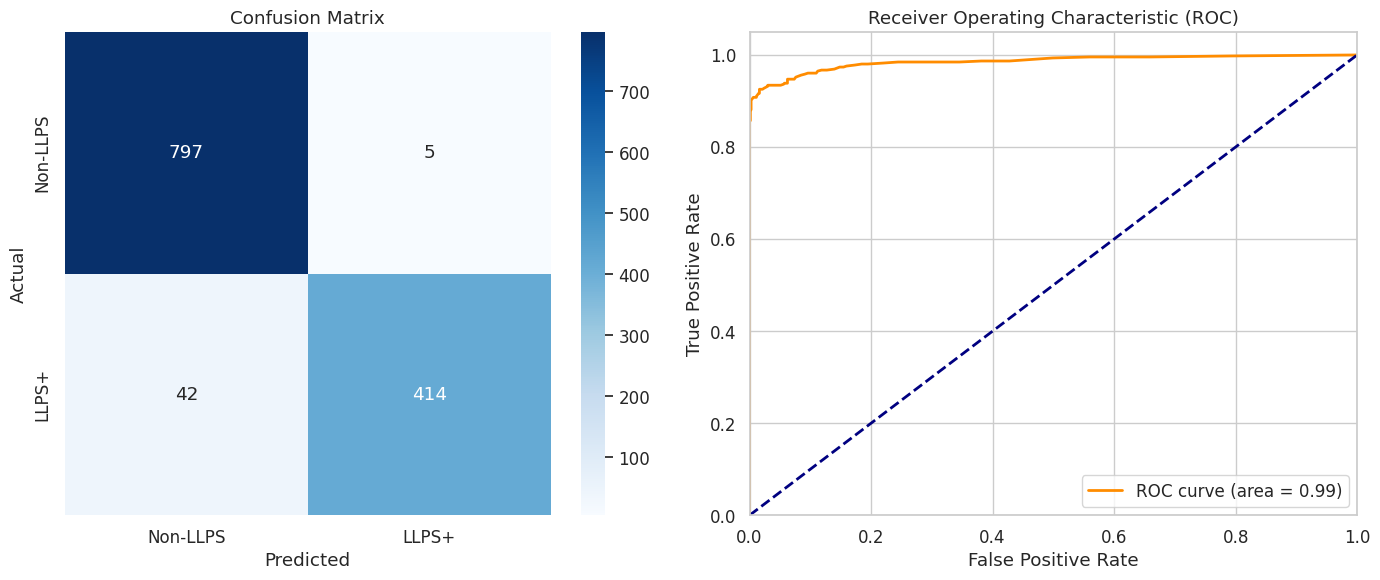

1. dim_74 (0.0614)
2. IDR_Fraction (0.0591)
3. dim_67 (0.0406)
4. dim_34 (0.0331)
5. dim_11 (0.0328)
6. dim_9 (0.0319)
7. Hydrophobicity (0.0294)
8. dim_17 (0.0274)
9. dim_83 (0.0266)
10. dim_26 (0.0252)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------------------------
# Define the list of features to use for training
# We combine the Biophysical Features (EF) with the Language Model Embeddings (LM)
ef_features = [
    'Length', 'Hydrophobicity', 'ShannonEntropy',
    'LCR_Fraction', 'IDR_Fraction',
    'LCR_Polar', 'LCR_Hydrophobic', 'LCR_Aromatic', 'LCR_Cationic', 'LCR_Anionic'
]
lm_features = [f'dim_{i}' for i in range(100)] # The 100 dimensions from Word2Vec

feature_cols = ef_features + lm_features

# Drop any rows that might still have NaNs (just in case)
df_model = df_final.dropna(subset=feature_cols + ['Label']).copy()

X = df_model[feature_cols]
y = df_model['Label'].astype(int) # 1 for LLPS+, 0 for Non-LLPS

# Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape[0]} sequences")
print(f"Testing Data:  {X_test.shape[0]} sequences")

# ------------------------------------------------------------------------------
# 2. TRAIN MODEL
# ------------------------------------------------------------------------------
print("\nTraining Random Forest Classifier...")
# Parameters similar to standard baseline (100 trees)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✅ Model trained.")

# ------------------------------------------------------------------------------
# 3. EVALUATE PERFORMANCE
# ------------------------------------------------------------------------------
# Make predictions
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1] # Probability of being LLPS+

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probs)

print(f"\n--- Model Performance ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC:  {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-LLPS', 'LLPS+']))

# ------------------------------------------------------------------------------
# 4. VISUALIZE RESULTS
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-LLPS', 'LLPS+'], yticklabels=['Non-LLPS', 'LLPS+'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot B: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 5. FEATURE IMPORTANCE (Which features matter most?)
# ------------------------------------------------------------------------------
# Sort features by importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

for i in range(10):
    feat_name = feature_cols[indices[i]]
    print(f"{i+1}. {feat_name} ({importances[indices[i]]:.4f})")

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Neural Network Data Preparation Complete.")
print(f"Scaled Training Shape: {X_train_scaled.shape}")
print(f"Scaled Testing Shape:  {X_test_scaled.shape}")
print("\n--- Verification (First 5 values of first protein) ---")

print(f"After scaling: {np.round(X_train_scaled[0][:5], 3)}")

Neural Network Data Preparation Complete.
Scaled Training Shape: (5031, 110)
Scaled Testing Shape:  (1258, 110)

--- Verification (First 5 values of first protein) ---
After scaling: [ 0.111 -0.662  0.367  0.382  0.341]


🔄 Scaling data...
✅ Data Scaled. Input Shape: (5031, 110)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,297 (91.00 KB)

 Trainable params: 22,913 (89.50 KB)

 Non-trainable params: 384 (1.50 KB)


🚀 Starting Neural Network Training...
Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - AUC: 0.9492 - accuracy: 0.8960 - loss: 0.2832 - val_AUC: 0.9727 - val_accuracy: 0.9428 - val_loss: 0.1878
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9789 - accuracy: 0.9485 - loss: 0.1583 - val_AUC: 0.9791 - val_accuracy: 0.9467 - val_loss: 0.1579
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9805 - accuracy: 0.9505 - loss: 0.1478 - val_AUC: 0.9809 - val_accuracy: 0.9475 - val_loss: 0.1576
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9850 - accuracy: 0.9573 - loss: 0.1266 - val_AUC: 0.9833 - val_accuracy: 0.9555 - val_loss: 0.1667
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9855 - accuracy: 0.9581 - loss: 0.1247 - val_AUC: 0.9829 - val_accuracy: 0.9555 - val_loss: 0.1730
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9876 - accuracy: 0.9632 - loss: 0.1137 - val_AUC: 0.9837 - val_accuracy: 0.9563 - val_loss: 

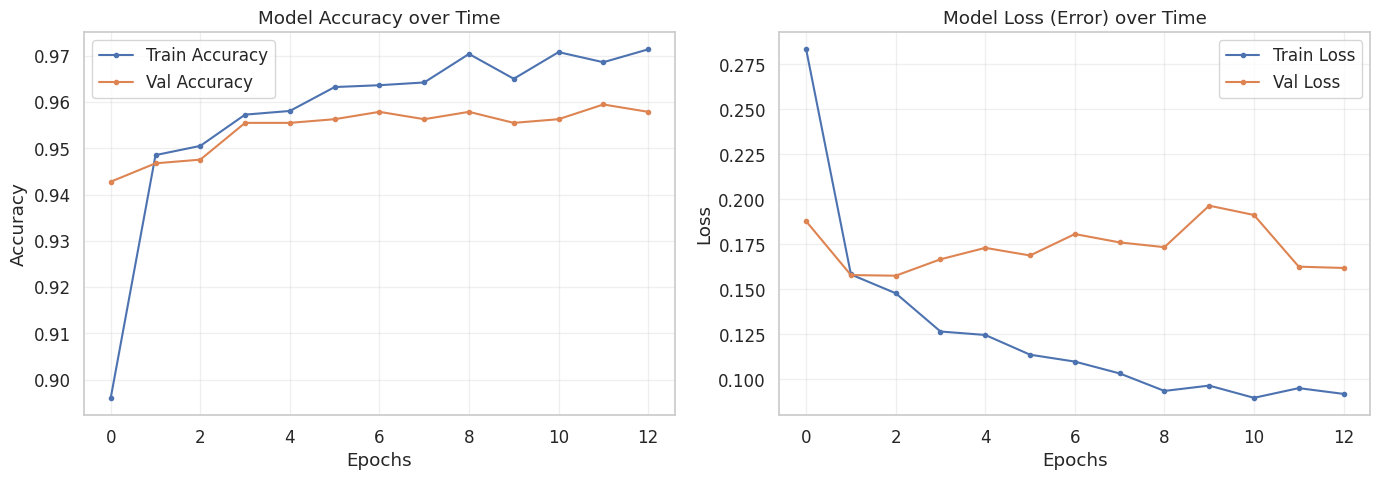

In [ ]:
# ==============================================================================
# NEURAL NETWORK IMPLEMENTATION (TensorFlow/Keras)
# ==============================================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------------------
# STEP 1: SCALING (CRITICAL FOR NEURAL NETWORKS)
# ------------------------------------------------------------------------------
# Neural Networks fail if data isn't scaled (e.g., Length=500 vs. Vector=0.01).
# We use the X_train/X_test already created in your Random Forest section.

print("🔄 Scaling data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data Scaled. Input Shape: {X_train_scaled.shape}")

# ------------------------------------------------------------------------------
# STEP 2: DEFINE THE MODEL ARCHITECTURE (MLP)
# ------------------------------------------------------------------------------
def build_llps_model(input_dim):
    model = Sequential([
        # Input Layer + Hidden Layer 1
        # 128 neurons to capture complex patterns in the 210 features
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),  # Stabilizes training
        Dropout(0.3),          # Prevents overfitting (randomly ignores 30% neurons)

        # Hidden Layer 2
        # Compressing info to 64 neurons
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        # Output Layer
        # Sigmoid gives a probability score (0.0 to 1.0)
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',              # Best standard optimizer
        loss='binary_crossentropy',    # Math for Yes/No classification
        metrics=['accuracy', 'AUC']    # Track Accuracy and ROC-AUC
    )
    return model

# Initialize the model
model = build_llps_model(X_train_scaled.shape[1])
model.summary()

# ------------------------------------------------------------------------------
# STEP 3: TRAIN THE MODEL
# ------------------------------------------------------------------------------
print("\n🚀 Starting Neural Network Training...")

# Stop training if validation loss doesn't improve for 10 epochs (saves time)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,          # Max epochs (will likely stop earlier due to early_stop)
    batch_size=32,       # Learn from 32 proteins at a time
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------------------------
# STEP 4: EVALUATE & VISUALIZE
# ------------------------------------------------------------------------------
# Calculate final metrics
loss, acc, auc_score = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n🏆 Final Test Accuracy: {acc*100:.2f}%")
print(f"🏆 Final ROC-AUC:      {auc_score:.4f}")

# Plot Training History
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='.')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='.')
plt.title('Model Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='.')
plt.plot(history.history['val_loss'], label='Val Loss', marker='.')
plt.title('Model Loss (Error) over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 5: SAVE THE MODEL (Optional but recommended)
# ------------------------------------------------------------------------------
# model.save('llps_neural_network.h5')
# print("Model saved as llps_neural_network.h5")

CNN Input Shape: (5031, 110, 1) (samples, features, channels)
Each sample: 110 timesteps × 1 channel(s)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 110, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 110, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 55, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 55, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 55, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 55, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 27, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 27, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 27, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 27, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 832)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        53,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,513 (470.75 KB)

 Trainable params: 120,001 (468.75 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9002 - auc: 0.9493 - loss: 0.2791 - val_accuracy: 0.8824 - val_auc: 0.9657 - val_loss: 0.3886
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9453 - auc: 0.9771 - loss: 0.1653 - val_accuracy: 0.9300 - val_auc: 0.9746 - val_loss: 0.2109
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9521 - auc: 0.9824 - loss: 0.1394 - val_accuracy: 0.9436 - val_auc: 0.9756 - val_loss: 0.1692
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9581 - auc: 0.9854 - loss: 0.1249 - val_accuracy: 0.9412 - val_auc: 0.9771 - val_loss: 0.1777
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9606 - auc: 0.9868 - loss: 0.1174 - val_accuracy: 0.9412 - val_auc: 0.9768 - val_loss: 0.1672
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9634 - auc: 0.9890 - loss: 0.1065 - val_accuracy: 0.9499 - val_auc: 0.9782 - val_loss: 0.1651
Epoch 7/100
158/158 ━━━━━━━━━━━━

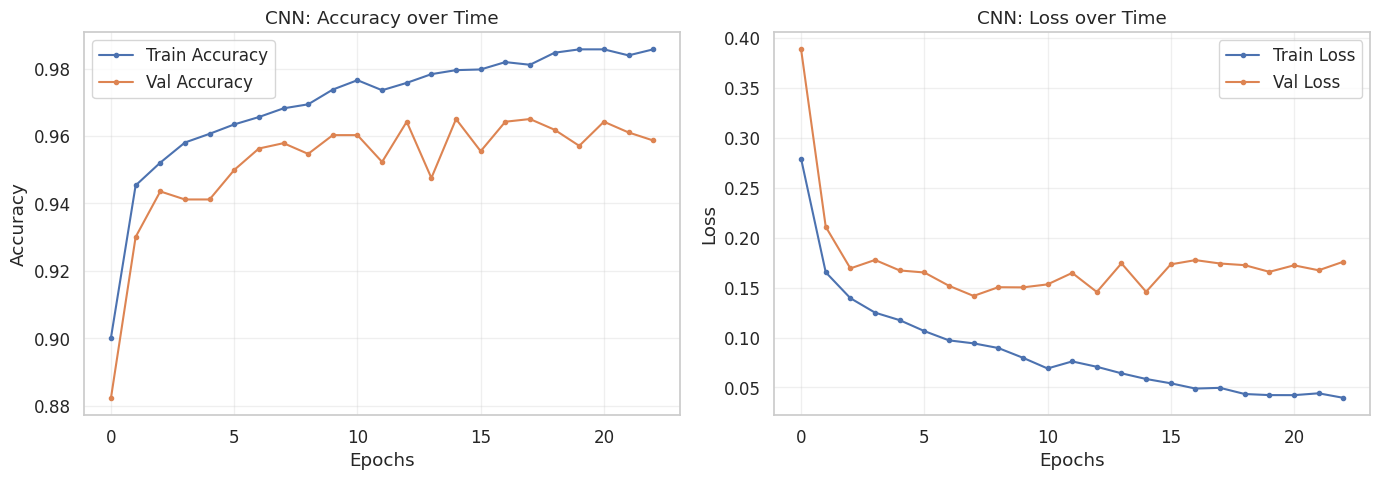

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


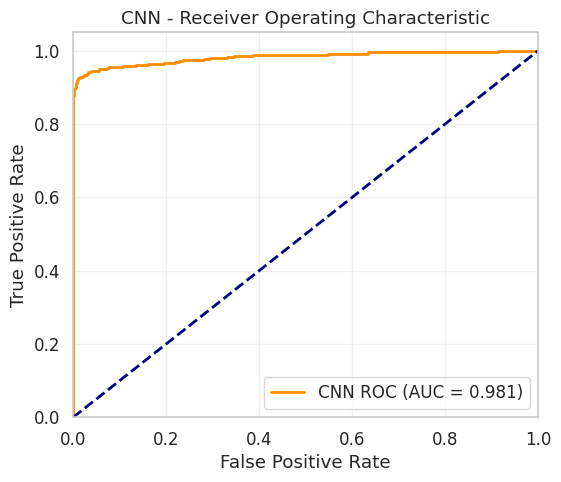


CNN implementation complete. Compare AUC with MLP and Random Forest.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"CNN Input Shape: {X_train_cnn.shape} (samples, features, channels)")
print(f"Each sample: {X_train_cnn.shape[1]} timesteps × {X_train_cnn.shape[2]} channel(s)")


def build_cnn_model(input_shape):
    model = Sequential([
        # Conv Block 1
        Conv1D(64, kernel_size=5, activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Conv Block 2
        Conv1D(128, kernel_size=5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Conv Block 3
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        # Classifier Head
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

cnn_model = build_cnn_model((X_train_cnn.shape[1], X_train_cnn.shape[2]))
cnn_model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


loss_cnn, acc_cnn, auc_cnn = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\n🏆 CNN Test Accuracy: {acc_cnn*100:.2f}%")
print(f"🏆 CNN ROC-AUC:      {auc_cnn:.4f}")

# Plot Training History
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy', marker='.')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy', marker='.')
plt.title('CNN: Accuracy over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss', marker='.')
plt.plot(history_cnn.history['val_loss'], label='Val Loss', marker='.')
plt.title('CNN: Loss over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ROC Curve
from sklearn.metrics import roc_curve, auc
y_probs_cnn = cnn_model.predict(X_test_cnn).flatten()
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_probs_cnn)
plt.figure(figsize=(6, 5))
plt.plot(fpr_cnn, tpr_cnn, color='darkorange', lw=2, label=f'CNN ROC (AUC = {auc_cnn:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('CNN - Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print("\nCNN implementation complete. Compare AUC with MLP and Random Forest.")

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalMaxPooling1D, Embedding, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model

MAX_LEN = 1000  # Cutoff length (covers most proteins)
EMBEDDING_DIM = 100 # Must match your Word2Vec size

vocab = w2v_model.wv.key_to_index
vocab_size = len(vocab) + 1  # +1 for the zero padding

embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
for word, i in vocab.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]


def sequence_to_indices(sequence, vocab_map, max_len):
    # Get 3-grams
    grams = [sequence[i:i+3] for i in range(len(sequence) - 2)]
    # Convert to Integers
    indices = [vocab_map[g] for g in grams if g in vocab_map]
    return indices

print("Tokenizing and padding sequences for CNN...")
X_seq_indices = [sequence_to_indices(seq, vocab, MAX_LEN) for seq in df_final['Sequence']]


X_seq_padded = pad_sequences(X_seq_indices, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Sequence Data Shape: {X_seq_padded.shape}")

Tokenizing and padding sequences for CNN...
Sequence Data Shape: (6289, 1000)


In [ ]:

biophys_cols = [
    'Length', 'Hydrophobicity', 'ShannonEntropy',
    'LCR_Fraction', 'IDR_Fraction',
    'LCR_Polar', 'LCR_Hydrophobic', 'LCR_Aromatic', 'LCR_Cationic', 'LCR_Anionic'
]
X_biophys = df_final[biophys_cols].values


from sklearn.model_selection import train_test_split

X_seq_train, X_seq_test, X_bio_train, X_bio_test, y_train, y_test = train_test_split(
    X_seq_padded,
    X_biophys,
    df_final['Label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_final['Label'].values
)

# 3. Scale the Biophysical features independently (StandardScaler)
from sklearn.preprocessing import StandardScaler
scaler_bio = StandardScaler()
X_bio_train = scaler_bio.fit_transform(X_bio_train)
X_bio_test = scaler_bio.transform(X_bio_test)

print("Data ready for Hybrid CNN.")

Data ready for Hybrid CNN.


In [ ]:
def build_hybrid_cnn(vocab_size, embedding_dim, embedding_matrix, max_len, num_biophys_features):

    seq_input = Input(shape=(max_len,), name="Sequence_Input")


    x1 = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False # Keep True if you want to fine-tune embeddings
    )(seq_input)

    # Convolutional Block
    x1 = Conv1D(filters=64, kernel_size=5, activation='relu')(x1)
    x1 = BatchNormalization()(x1)
    x1 = GlobalMaxPooling1D()(x1) # Grabs the strongest signal (motif) found anywhere in sequence
    x1 = Dropout(0.3)(x1)

    # --- BRANCH 2: Dense Network for Biophysical Features ---
    bio_input = Input(shape=(num_biophys_features,), name="Biophysical_Input")
    x2 = Dense(32, activation='relu')(bio_input)
    x2 = BatchNormalization()(x2)

    # --- MERGE ---
    merged = Concatenate()([x1, x2])

    # Classification Head
    z = Dense(64, activation='relu')(merged)
    z = Dropout(0.3)(z)
    output = Dense(1, activation='sigmoid')(z)

    model = Model(inputs=[seq_input, bio_input], outputs=output)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 'AUC']
    )
    return model

# Initialize
cnn_model = build_hybrid_cnn(
    vocab_size=vocab_size,
    embedding_dim=EMBEDDING_DIM,
    embedding_matrix=embedding_matrix,
    max_len=MAX_LEN,
    num_biophys_features=X_bio_train.shape[1]
)

cnn_model.summary()

# Train
print("\nTraining Hybrid CNN...")
history_cnn = cnn_model.fit(
    x=[X_seq_train, X_bio_train], # Two inputs!
    y=y_train,
    validation_data=([X_seq_test, X_bio_test], y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop], # Using the EarlyStopping you defined earlier
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Sequence_Input      │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1000, 100) │    804,100 │ Sequence_Input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 996, 64)   │     32,064 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 996, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Biophysical_Input   │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │        352 │ Biophysical_Inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dropout_6[0][0],  │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 843,173 (3.22 MB)

 Trainable params: 38,881 (151.88 KB)

 Non-trainable params: 804,292 (3.07 MB)


Training Hybrid CNN...
Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - AUC: 0.8569 - accuracy: 0.8080 - loss: 0.6151 - val_AUC: 0.9761 - val_accuracy: 0.9444 - val_loss: 0.1725
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.9571 - accuracy: 0.9157 - loss: 0.2379 - val_AUC: 0.9782 - val_accuracy: 0.9467 - val_loss: 0.1526
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - AUC: 0.9724 - accuracy: 0.9304 - loss: 0.1833 - val_AUC: 0.9798 - val_accuracy: 0.9507 - val_loss: 0.1414
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - AUC: 0.9775 - accuracy: 0.9392 - loss: 0.1630 - val_AUC: 0.9804 - val_accuracy: 0.9523 - val_loss: 0.1339
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - AUC: 0.9790 - accuracy: 0.9479 - loss: 0.1531 - val_AUC: 0.9821 - val_accuracy: 0.9571 - val_loss: 0.1295
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.9826 - accuracy: 0.9499 - loss: 0.1420 - val_AUC: 0.9827 - val_accuracy: 0.9547 - val_loss: 0.1313
Epoch 7/50
158

In [ ]:
loss, acc, auc = cnn_model.evaluate([X_seq_test, X_bio_test], y_test)
print(f"\nExample CNN Results:")
print(f"Accuracy: {acc:.4f}")
print(f"AUC:      {auc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - AUC: 0.9901 - accuracy: 0.9634 - loss: 0.0985

Example CNN Results:
Accuracy: 0.9634
AUC:      0.9901


In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tqdm.notebook import tqdm # Ensure tqdm is imported for progress bar

print("🚀 Initiating High-Throughput LLPS Discovery Pipeline...")

# =======================================================
# STEP 1: LOAD THE UNLABELED DATA
# =======================================================
df_mass = pd.read_csv('merged_llps_unique.csv')

# Ensure the sequence column is consistent for feature calculation
# The original CSV has 'sequence' (lowercase), but our functions expect 'Sequence'
if 'Sequence' not in df_mass.columns and 'sequence' in df_mass.columns:
    df_mass.rename(columns={'sequence': 'Sequence'}, inplace=True)

print(f"Loaded {len(df_mass)} unique protein sequences for mass screening.")

# =======================================================
# STEP 2: PREPROCESS THE 6,289 SEQUENCES
# =======================================================
print("⚙️ Processing Sequences and Biophysical Features...")

# --- A. Biophysical Feature Extraction ---
# These functions (calculate_shannon_entropy, calculate_hydrophobicity_sum,
# calculate_idr_fraction, analyze_lcr_properties) were defined in previous cells
# and are globally available. We need to re-calculate them for df_mass.

print("- Calculating Length...")
df_mass['Length'] = df_mass['Sequence'].apply(len)

print("- Calculating Hydrophobicity (Sum)...")
df_mass['Hydrophobicity'] = df_mass['Sequence'].apply(calculate_hydrophobicity_sum)

print("- Calculating Shannon Entropy...")
df_mass['ShannonEntropy'] = df_mass['Sequence'].apply(calculate_shannon_entropy)

print("- Calculating IDR Fraction...")
df_mass['IDR_Fraction'] = [calculate_idr_fraction(seq) for seq in tqdm(df_mass['Sequence'], desc="IDR")]

print("- Analyzing LCR Composition...")
lcr_features_mass = df_mass['Sequence'].apply(lambda s: analyze_lcr_properties(s))
df_mass = pd.concat([df_mass, lcr_features_mass], axis=1)

# --- Handle potential NaNs before scaling ---
df_mass[biophys_cols] = df_mass[biophys_cols].fillna(0)

# Extract the 10 calculated columns as a NumPy array
X_bio_mass = df_mass[biophys_cols].values

# Scale using the EXACT SAME scaler from training (NO fit_transform)
X_bio_mass_scaled = scaler_bio.transform(X_bio_mass)

# --- B. Sequence Tokenization ---
print("🧬 Tokenizing and padding sequences...")
X_seq_mass_indices = [sequence_to_indices(seq, vocab, MAX_LEN) for seq in df_mass['Sequence']]
X_seq_mass_padded = pad_sequences(X_seq_mass_indices, maxlen=MAX_LEN, padding='post', truncating='post')

# =======================================================
# STEP 3: RUN THE HYBRID CNN PREDICTIONS
# =======================================================
print("\n🤖 Running Hybrid CNN Prediction Engine... This may take a moment.")

# Get exact probability percentages (e.g., 0.982 = 98.2% chance of LLPS)
y_pred_probs = cnn_model.predict([X_seq_mass_padded, X_bio_mass_scaled]).flatten()

# Convert probabilities to a strict label (1 for LLPS, 0 for Structured) using a 50% cutoff
y_pred_labels = (y_pred_probs >= 0.5).astype(int)

# =======================================================
# STEP 4: APPEND RESULTS AND SAVE
# =======================================================
# Add the AI's predictions directly into the Pandas DataFrame
df_mass['LLPS_Probability'] = np.round(y_pred_probs, 4)
df_mass['Predicted_LLPS_Class'] = y_pred_labels

# Map the 1s and 0s to human-readable text for the final CSV
df_mass['Prediction_Text'] = df_mass['Predicted_LLPS_Class'].map({1: 'Likely LLPS', 0: 'Structured / Non-LLPS'})

# Save the final annotated dataset
output_filename = 'CNN_Annotated_LLPS_Predictions.csv'
df_mass.to_csv(output_filename, index=False)

# =======================================================
# STEP 5: DISCOVERY SUMMARY
# =======================================================
total_llps_found = np.sum(y_pred_labels)
percentage_llps = (total_llps_found / len(df_mass)) * 100

print("\n🏆 --- MASS SCREENING COMPLETE --- 🏆")
print(f"File saved successfully as: {output_filename}")
print(f"Total Sequences Screened: {len(df_mass)}")
print(f"🧬 Model identified {total_llps_found} sequences ({percentage_llps:.1f}%) as Liquid-Liquid Phase Separating.")
print("\nTop 5 Highest Confidence LLPS Candidates:")
# Sort by highest probability and show the top 5
print(df_mass[df_mass['Predicted_LLPS_Class'] == 1].sort_values(by='LLPS_Probability', ascending=False)[['Sequence', 'LLPS_Probability']].head())

🚀 Initiating High-Throughput LLPS Discovery Pipeline...
Loaded 6289 unique protein sequences for mass screening.
⚙️ Processing Sequences and Biophysical Features...
- Calculating Length...
- Calculating Hydrophobicity (Sum)...
- Calculating Shannon Entropy...
- Calculating IDR Fraction...


IDR:   0%|          | 0/6289 [00:00<?, ?it/s]

- Analyzing LCR Composition...
🧬 Tokenizing and padding sequences...

🤖 Running Hybrid CNN Prediction Engine... This may take a moment.
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

🏆 --- MASS SCREENING COMPLETE --- 🏆
File saved successfully as: CNN_Annotated_LLPS_Predictions.csv
Total Sequences Screened: 6289
🧬 Model identified 2256 sequences (35.9%) as Liquid-Liquid Phase Separating.

Top 5 Highest Confidence LLPS Candidates:
                                               Sequence  LLPS_Probability
2281  MVMEKPSPLLVGREFVRQYYTLLNKAPDFLHRFYGRNSSYVHGGLD...               1.0
0     MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTD...               1.0
2241  MVMEKPSPLLVGREFVRQYYTLLNKAPDFLHRFYGRNSSYVHGGLD...               1.0
2242  QKYGYFHCKDCKTRWESAYVWCISGSNKVVYFKQLCRKCQKGFNPY...               1.0
2243  MDELVVEVRGTSGAFYKAFIKDVHEGSVTVAFENNWQPERQIPFQD...               1.0


In [1]:
!pip freeze > requirements.txt